<a href="https://colab.research.google.com/github/selfmusing94/lab/blob/main/dl_lab_prgs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement a simple neural network from scratch. • Implement a perceptron. • Train the perceptron on a simple dataset (e.g., AND, OR logic gates). • Visualize the decision boundary.



Accuracy: 1.0
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


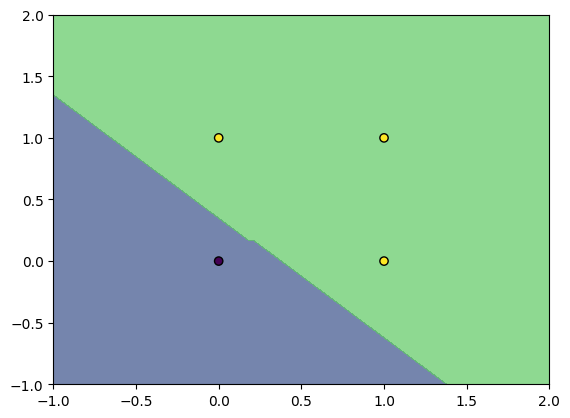

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Fix randomness
np.random.seed(0)
tf.random.set_seed(0)

# Data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])
#or gate
#y = np.array([0,1,1,1])

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# Use same learning rate as original
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X, y, epochs=1000, verbose=0)

# Evaluate
print("Accuracy:", model.evaluate(X, y, verbose=0)[1])

# Plot
xx, yy = np.meshgrid(np.linspace(-1,2,100), np.linspace(-1,2,100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z > 0.5, alpha=0.7)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.show()

Build a feedforward neural network using a deep learning framework. • Create a simple feedforward neural network using TensorFlow/Keras or PyTorch. • Train the network on the MNIST dataset. • Evaluate the model's accuracy and visualize some predictions.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9159 - loss: 0.2928 - val_accuracy: 0.9513 - val_loss: 0.1647
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9607 - loss: 0.1315 - val_accuracy: 0.9632 - val_loss: 0.1250
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9743 - loss: 0.0885 - val_accuracy: 0.9658 - val_loss: 0.1123
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9817 - loss: 0.0642 - val_accuracy: 0.9679 - val_loss: 0.1057
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9868 - loss: 0.0475 - val_accuracy: 0.9709 - val_loss: 0.1019
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9714 - loss: 0.0947
Test Accuracy: 0.9714000225067139


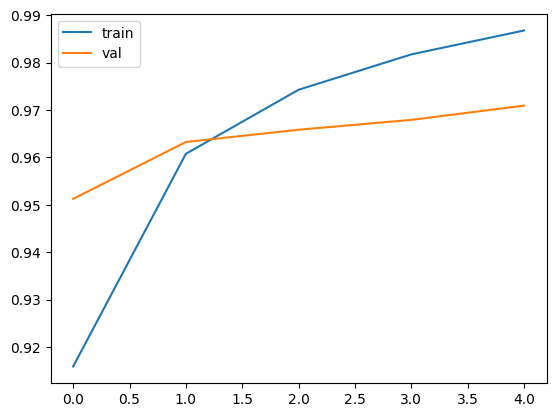

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


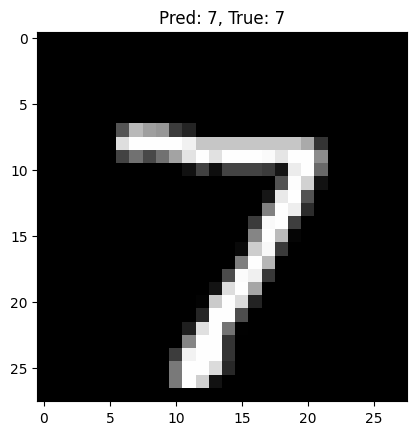

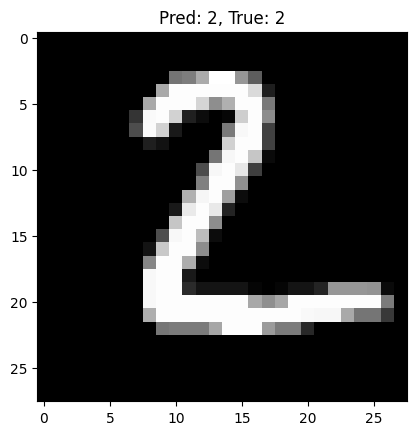

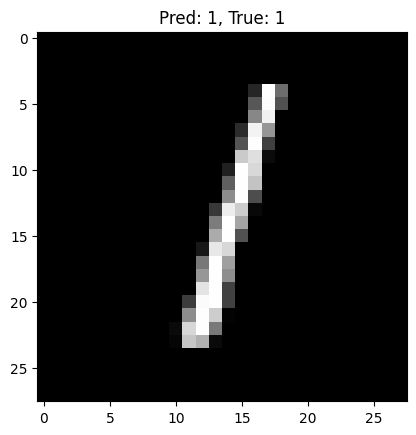

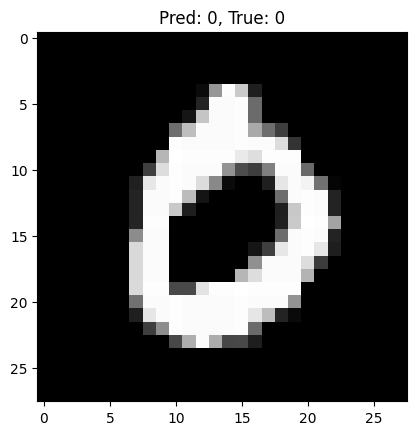

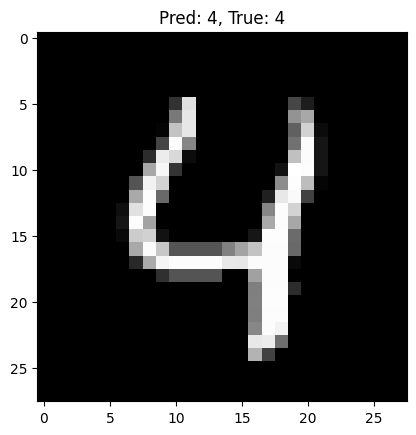

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST (inbuilt)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess
X_train, X_test = X_train/255.0, X_test/255.0

# Model (Feedforward NN)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Evaluate
print("Test Accuracy:", model.evaluate(X_test, y_test)[1])

# Plot accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

# Show predictions
pred = model.predict(X_test[:5])
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {np.argmax(pred[i])}, True: {y_test[i]}")
    plt.show()

Explore different activation functions and their effects on training. • Implement different activation functions (e.g., Sigmoid, ReLU, Tanh). • Train a neural network on the MNIST dataset using each activation function. • Compare and visualize the training performance and accuracy.

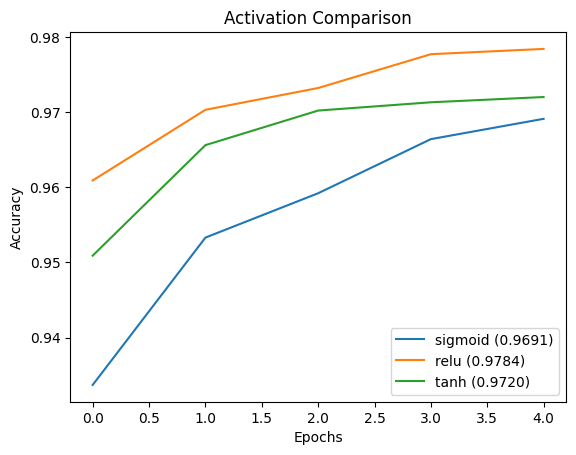

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# FIX: ensure correct dtype
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Model function
def build_model(act):
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation=act),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

activations = ['sigmoid', 'relu', 'tanh']
history = {}

# Train
for act in activations:
    model = build_model(act)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history[act] = model.fit(X_train, y_train, epochs=5,
                            validation_data=(X_test, y_test), verbose=0)

# Plot
for act in activations:
    acc = history[act].history['val_accuracy'][-1]
    plt.plot(history[act].history['val_accuracy'], label=f"{act} ({acc:.4f})")

plt.legend()
plt.title("Activation Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

Understand the impact of different optimizers on the training process. • Implement various optimizers (e.g., SGD, Adam, RMSprop). • Train a neural network on the CIFAR-10 dataset using each optimizer. • Compare the convergence speed and final accuracy of each optimizer.

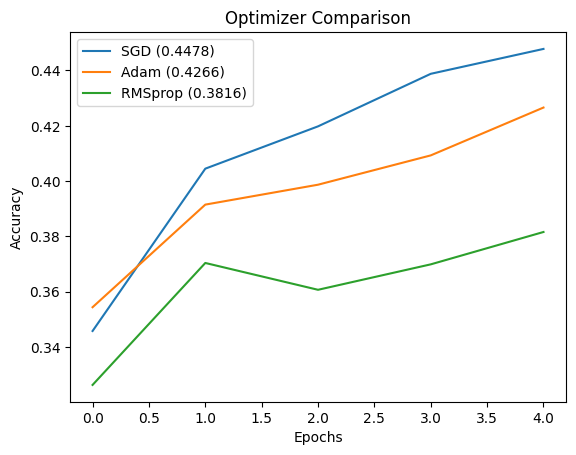

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train, X_test = X_train/255.0, X_test/255.0

# Model
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32,32,3)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

optimizers = {
    'SGD': tf.keras.optimizers.SGD(),
    'Adam': tf.keras.optimizers.Adam(),
    'RMSprop': tf.keras.optimizers.RMSprop()
}

history = {}

# Train models
for name, opt in optimizers.items():
    model = build_model()
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history[name] = model.fit(X_train, y_train,
                              epochs=5,
                              validation_data=(X_test, y_test),
                              verbose=0)

# Plot comparison
for name in optimizers:
    acc = history[name].history['val_accuracy'][-1]
    plt.plot(history[name].history['val_accuracy'],
             label=f"{name} ({acc:.4f})")

plt.title("Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Learn how regularization techniques can improve model generalization. • Implement L2 regularization and dropout. • Train a neural network on the Fashion MNIST dataset with and without regularization. • Visualize the effect of regularization on training and validation loss.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7500 - loss: 0.7443 - val_accuracy: 0.8152 - val_loss: 0.5400
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8127 - loss: 0.5807 - val_accuracy: 0.8400 - val_loss: 0.4973
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8261 - loss: 0.5452 - val_accuracy: 0.8480 - val_loss: 0.4852
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8326 - loss: 0.5314 - val_accuracy: 0.8481 - val_loss: 0.4793
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8363 - loss: 0.5256 - val_accuracy: 0.8517 - val_loss: 0.4756
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8390 - loss: 0.5161 - val_accuracy: 0.8528 - val_loss: 0.4685
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8416 - loss: 0.5150 - val_accuracy: 0.8594 - val_loss: 0.4616
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8447 - loss: 0

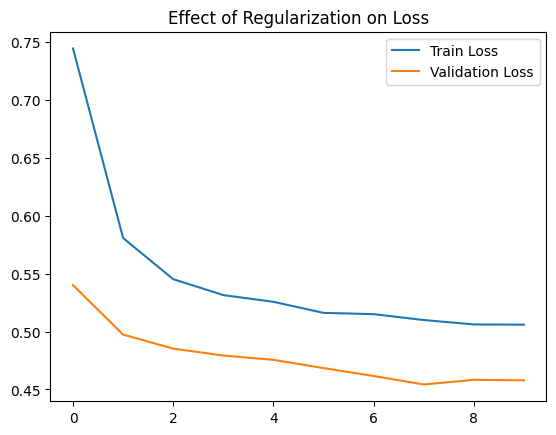

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset from TensorFlow
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values (scale between 0 and 1)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images to 28x28 (already in correct shape, but keeping for consistency)
train_images = train_images.reshape(-1, 28, 28)
test_images = test_images.reshape(-1, 28, 28)

# Define model with dropout and L2 regularization
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

# Visualize loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Effect of Regularization on Loss")
plt.show()

Implement a simple CNN and understand its applications in image recognition. • Build a simple CNN using TensorFlow/Keras or PyTorch. • Train the CNN on the MNIST dataset. • Evaluate the model's performance and visualize the learned filters.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.9518 - loss: 0.1597 - val_accuracy: 0.9755 - val_loss: 0.0797
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9840 - loss: 0.0503 - val_accuracy: 0.9877 - val_loss: 0.0425
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9890 - loss: 0.0352 - val_accuracy: 0.9852 - val_loss: 0.0493
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9917 - loss: 0.0265 - val_accuracy: 0.9831 - val_loss: 0.0574
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9939 - loss: 0.0197 - val_accuracy: 0.9887 - val_loss: 0.0410
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9939 - loss: 0.0201
Accuracy: 0.9939
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


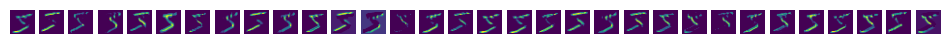

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Load & Preprocess
(X, y), _ = keras.datasets.mnist.load_data()
X = X.reshape(-1, 28, 28, 1) / 255.0
y = keras.utils.to_categorical(y, 10)

# Build Model
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)
model = keras.Model(inputs, outputs)

# Compile & Train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=5, batch_size=32, validation_split=0.2)

# Evaluate
_, acc = model.evaluate(X, y)
print(f"Accuracy: {acc:.4f}")

# Visualize Filters
conv_outputs = [l.output for l in model.layers if isinstance(l, layers.Conv2D)]
act_model = keras.Model(inputs, conv_outputs)
activations = act_model.predict(X[0].reshape(1, 28, 28, 1))

fig, axes = plt.subplots(1, activations[0].shape[-1], figsize=(12, 6))
for i, ax in enumerate(axes):
    ax.imshow(activations[0][0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.show()

Explore RNNs and their applications in sequence data. • Implement a simple RNN for text classification. • Train the RNN on a dataset of your choice (e.g., sentiment analysis dataset). • Evaluate the model's accuracy and visualize some predictions.

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6658 - loss: 0.5747 - val_accuracy: 0.7844 - val_loss: 0.4570
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8392 - loss: 0.3740 - val_accuracy: 0.7908 - val_loss: 0.4473
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8916 - loss: 0.2699 - val_accuracy: 0.7821 - val_loss: 0.5247
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9328 - loss: 0.1814 - val_accuracy: 0.7664 - val_loss: 0.6144
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9618 - loss: 0.1117 - val_accuracy: 0.7612 - val_loss: 0.7333


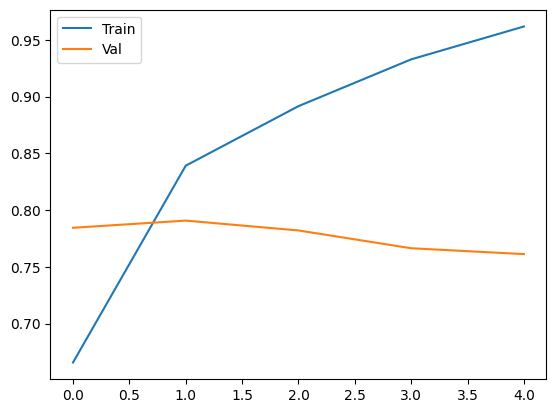

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Positive


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Load built-in IMDB dataset (positive / negative reviews)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=20000)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=35, padding='post')
x_test  = pad_sequences(x_test,  maxlen=35, padding='post')

# One-hot encode labels
y_train = to_categorical(y_train, 2)
y_test  = to_categorical(y_test,  2)

# Build & Train Model
model = Sequential([
    Embedding(20000, 5, input_length=35),
    SimpleRNN(32), #SimpleRNN(32, dropout=0.2)
    Dense(2, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Plot Accuracy
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.show()

# Predict Function (IMDB word index is offset by 3)
word_index = imdb.get_word_index()
labels = ['Negative', 'Positive']

def predict(text):
    seq = [[word_index.get(w, 0) + 3 for w in text.lower().split()]]
    seq = pad_sequences(seq, maxlen=35, padding='post')
    print(labels[model.predict(seq).argmax()])

predict("The movie was bad I will not recommend it")
predict("The movie was good I will recommend it")

Understand how to use pre-trained models for transfer learning. • Load a pre-trained model (e.g., VGG16, ResNet) using TensorFlow/Keras or PyTorch. • Fine-tune the model on a custom dataset (e.g., flower classification). • Evaluate the model's performance and visualize some predictions.

Found 3670 files belonging to 5 classes.
Using 2569 files for training.
Found 3670 files belonging to 5 classes.
Using 1101 files for validation.
Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
81/81 ━━━━━━━━━━━━━━━━━━━━ 42s 488ms/step - accuracy: 0.6613 - loss: 2.0578 - val_accuracy: 0.7929 - val_loss: 0.5974
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.7929 - loss: 0.5974
Loss: 0.5974  Accuracy: 0.7929


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step


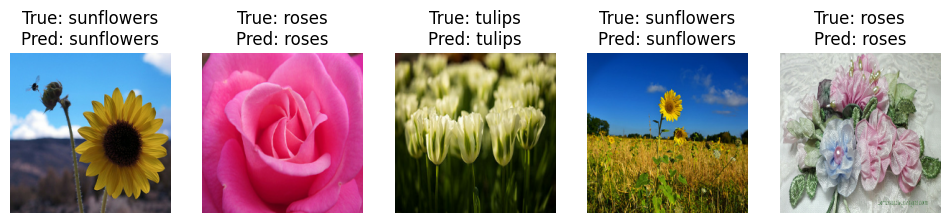

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# ─── DATASET LOADING — USE ONE OF THE TWO OPTIONS BELOW ───

# OPTION 1: Online (internet required) — comment this out if offline
data_dir = tf.keras.utils.get_file('flower_photos',
    origin="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    untar=True)
data_dir = data_dir + "/flower_photos"  # ← fix: extracted folder is nested one level deep

# OPTION 2: Offline (if ma'am gives the folder) — uncomment this line & comment OPTION 1
# data_dir = "./flower_photos"   # <-- change path to wherever the folder is

# ──────────────────────────────────────────────────────────

# Load as dataset
train_ds = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.3,
            subset='training',   seed=42, image_size=(224,224), batch_size=32)
val_ds   = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.3,
            subset='validation', seed=42, image_size=(224,224), batch_size=32)

flower_names = train_ds.class_names
print("Classes found:", flower_names)

# Normalize & one-hot encode
train_ds = train_ds.map(lambda x, y: (x/255.0, tf.one_hot(y, 5)))
val_ds   = val_ds.map(lambda x, y:   (x/255.0, tf.one_hot(y, 5)))

# Build Model
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3))
vgg.trainable = False

model = Sequential([vgg, Flatten(), Dense(512, activation='relu'), Dense(5, activation='softmax')])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(train_ds, epochs=1, validation_data=val_ds)

# Evaluate
loss, acc = model.evaluate(val_ds)
print(f"Loss: {loss:.4f}  Accuracy: {acc:.4f}")

# Visualize Predictions
images, labels = next(iter(val_ds))
preds = model.predict(images[:5]).argmax(axis=1)

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i]); plt.axis('off')
    plt.title(f"True: {flower_names[labels[i].numpy().argmax()]}\nPred: {flower_names[preds[i]]}")
plt.show()